# Imports

In [1]:
import sys
import os

#sys.path.append("/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")
#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/graphnet/lib/python3.8/site-packages/")

import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize, TwoSlopeNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable  # for neat colorbar placement



import numpy as np

#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")

#sys.path.insert(0,"/software/local/languages/miniforge3/envs/tensorflow/lib/python3.12/site-packages")

sys.path.insert(0,"/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/")

sys.path.insert(0,"/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages")

sys.path.insert(0, "/user/work/kr21883/")


print(sys.path)

import torch
import os
import pickle
import einops


import xarray as xr
from glob import glob
from scipy.stats import pearsonr
import matplotlib.animation as animation

#import plenoptic as po

#sys.path.insert(0, "/user/work/kr21883/GCN/graphnet/")
from graphnet_LPDM_emulator.model.layers.encoder import *
from graphnet_LPDM_emulator.model.layers.decoder import *
from graphnet_LPDM_emulator.model.layers.processor import *
from graphnet_LPDM_emulator.model.layers.graph_net_block import *
from graphnet_LPDM_emulator.model.data.dataloader_graphnet import *
from graphnet_LPDM_emulator.model.data.load_data import *
from graphnet_LPDM_emulator.model.forecast import GraphSatelliteForecaster
from graphnet_LPDM_emulator.model.loss_functions import *
from graphnet_LPDM_emulator.model.evaluation import *
from graphnet_LPDM_emulator.model.metrics_and_figures import *

import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import time
from datetime import datetime
import json
import argparse

import random

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import timeit

['/user/work/kr21883/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python312.zip', '/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12', '/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/lib-dynload', '', '/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages']
['/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/work/kr21883/', '/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages', '/software/local/languages/miniforge3/envs/elena/lib/python3.12/site-packages/', '/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python312.zip', '/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12'

# Functions

In [87]:
def plot_mean_with_uncertainty(ax, models, key, label=None, color=None, max_len=100):
    ### For the training metrics
    values = []
    for mod in models:
        if key in mod:
            data = mod[key]
            if isinstance(data, dict):
                data = data["R2"]
            values.append(np.array(data[:max_len]))
    
    if not values:
        return

    values = np.stack(values)  # shape: (num_models, time)
    mean = np.mean(values, axis=0)
    std = np.std(values, axis=0)

    x = np.arange(len(mean))
    ax.plot(x, mean, label=label, color=color)
    ax.fill_between(x, mean - std, mean + std, alpha=0.3, color=color)


# Local helper function to save inside summary_outputs
def save_path(filename):
    return os.path.join(summary_dir, filename)

# For animated visualation of uncertainty
def animate_dataarray(da, title_prefix, filename, cmap="viridis", interval=300, vmin=None, vmax=None, save_dir="."):
    """
    Creates and saves an animation of a spatio-temporal xarray.DataArray.

    Parameters:
    - da: xarray.DataArray with dimensions including 'time', 'lat', and 'lon'
    - title_prefix: string, e.g., 'Mean Prediction'
    - filename: string, e.g., 'mean_prediction.gif'
    - cmap: matplotlib colormap string
    - interval: int, milliseconds between frames
    - vmin, vmax: floats, fixed colorbar limits (optional)
    - save_dir: directory to save the gif in
    """

    fig, ax = plt.subplots()
    da0 = da.isel(time=0)
    img = da0.plot(ax=ax, cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(img, ax=ax)
    cbar.set_label(title_prefix)

    def update(frame_idx):
        ax.clear()
        da_frame = da.isel(time=frame_idx)
        da_frame.plot(ax=ax, cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
        ax.set_title(f"{title_prefix} - Time {frame_idx}")
        return ax

    ani = animation.FuncAnimation(fig, update, frames=da.sizes["time"], interval=interval)
    output_path = os.path.join(save_dir, filename)
    ani.save(output_path, writer="pillow")
    plt.close()
    print(f"Saved animation: {output_path}")


def get_all_mole_fractions(flux_type="uniform"):
    if flux_type == "uniform":
        save_file = "mole_fractions.npz"
    elif flux_type == "actual":
        save_file = "mole_fractions_above_baseline.npz"

    if os.path.exists(save_file):
        print(f"Loading cached mole fraction arrays from {save_file}...")
        data = np.load(save_file)
        pred_mole_fractions = data["pred"]
        true_mole_fractions = data["true"]
        print(f"Loaded shapes: pred={pred_mole_fractions.shape}, true={true_mole_fractions.shape}")

    else:
        pred_mole_fractions = []
        true_mole_fractions = []

        for name in model_names:
            print(name)

            mod = ModelEv(
                name,
                size=50,
                validation_set="0[1-3]",
                test_set="*",
                val_year="2016",
                test_year="2016",
                check_validation_overlap=True,
                path_to_files="/group/chemistry/acrg/ef17148/trained_satellite_models/"
            )
            mod.get_adjusted_models(which="thr_only")

            if flux_type == "uniform":
                try:
                    mod.get_fluxes()
                    pred = mod.pred_fluxes.get("thr", None)
                    true = getattr(mod, "true_flux", None)

                    window_n = 5
                    window_size = 200
                    plt.plot(mod.true_flux[window_n*window_size:(1+window_n)*window_size])
                    plt.plot(mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])
                    plt.show()

                    if pred is not None and true is not None:
                        pred_mole_fractions.append(pred)
                        true_mole_fractions.append(true)
                    else:
                        print(f"Skipping model {mod.model_name} — fluxes missing")

                except Exception as e:
                    print(f"Error processing model {mod.model_name}: {e}")

            elif flux_type == "actual":
                # Load the Brazil map of fluxes
                brazil_fluxes = load_default_brazil_emissions()

                # Load the true footprints and select same timepoints as testing set
                true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
                true_fps = true_fps.sel(time=mod.preds_test.time)

                # Cut flux to match footprint release locations
                cut_flux = cut_emissions_data(brazil_fluxes, true_fps, 50)
                cut_flux = cut_flux.transpose([2, 0, 1])

                # Compute mole fraction with cut data
                mod.get_fluxes(cut_flux)

                pred = mod.pred_fluxes.get("thr", None)
                true = getattr(mod, "true_flux", None)

                # Optional quick visual check
                window_n = 3
                window_size = 200
                plt.plot(1e9 * mod.true_flux[window_n*window_size:(1+window_n)*window_size])
                plt.plot(1e9 * mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])
                plt.ylabel("ppb")
                plt.show()

                if pred is not None and true is not None:
                    pred_mole_fractions.append(pred)
                    true_mole_fractions.append(true)
                else:
                    print(f"Skipping model {mod.model_name} — mole_fractions missing")

        # Stack and save
        pred_mole_fractions = np.stack(pred_mole_fractions, axis=0)  # shape: (models, time)
        true_mole_fractions = np.stack(true_mole_fractions, axis=0)
        np.savez_compressed(save_file, pred=pred_mole_fractions, true=true_mole_fractions)

        print(f"Saved mole fraction arrays to {save_file}")

    return pred_mole_fractions, true_mole_fractions

def plot_mole_fraction(pred_mole_fractions, true_mole_fractions, flux_type="uniform", window_size=200):
    window_n = 5
    start = window_n * window_size
    end = (window_n + 1) * window_size

    pred_mole_fractions = np.stack(pred_mole_fractions, axis=0)  # shape: (n_models, time)
    true_mole_fractions = np.stack(true_mole_fractions, axis=0)

    for i in range(pred_mole_fractions.shape[0]):
        plt.plot(pred_mole_fractions[i, start:end], alpha=0.5, label=f"Model {i+1}")

    plt.plot(true_mole_fractions[0, start:end], alpha=0.5, color="black", label="True Mole Fraction")
    plt.legend()
    if flux_type == "uniform":
        plt.title("Mole fraction with uniform flux field")
        plt.savefig(save_path("flux_timeseries_overlay.png"))
    elif flux_type == "actual":
        plt.title("Mole fraction with true flux field (above baseline mole fractions)")
        plt.savefig(save_path("flux_timeseries_overlay_truefp.png"))
    plt.show()

def compute_mole_fraction_stats(pred_mole_fractions, true_mole_fractions):
    mean_mole_fraction = np.mean(pred_mole_fractions, axis=0)  # shape: (time,)
    std_mole_fraction = np.std(pred_mole_fractions, axis=0)    # shape: (time,)
    mean_true_mole_fraction = np.mean(true_mole_fractions, axis=0)  # Optional: mean ground truth across models
    normalised_mean_mole_fraction = mean_mole_fraction/mean_true_mole_fraction # normalised to the true footprint magnitude
    normalised_std_mole_fraction = std_mole_fraction/mean_true_mole_fraction # normalised to the true footprint magnitude

    return mean_mole_fraction, std_mole_fraction, mean_true_mole_fraction, normalised_mean_mole_fraction, normalised_std_mole_fraction

def plot_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, n_steps = 200, flux_type="uniform", plot="SD"):
    # Define number of time steps to plot
    
    mean_mole_fraction, std_mole_fraction, mean_true_mole_fraction, normalised_mean_mole_fraction, normalised_std_mole_fraction = compute_mole_fraction_stats(pred_mole_fractions, true_mole_fractions)

    # Slice data arrays
    mean_mole_fraction_subset = mean_mole_fraction[:n_steps]
    std_mole_fraction_subset = std_mole_fraction[:n_steps]
    mean_true_mole_fraction_subset = mean_true_mole_fraction[:n_steps]

    time = np.arange(n_steps)

    # Plot
    plt.figure(figsize=(10, 5))

    # Plot mean predicted mole_fraction with uncertainty band
    if plot == "SD":
        plt.plot(time, std_mole_fraction_subset, label="Uncertainty (SD) of Predicted Mole Fraction", color="tab:blue")
    if plot == "mean":
        plt.plot(time, mean_mole_fraction_subset, label="Uncertainty (SD) of Predicted Mole Fraction", color="tab:blue")
        plt.fill_between(time, 
                        mean_mole_fraction_subset + std_mole_fraction_subset, 
                        mean_mole_fraction_subset - std_mole_fraction_subset, 
                        alpha=0.3, color="tab:blue", label="±1 SD")

    # Plot ground truth
    plt.plot(time, mean_true_mole_fraction_subset, label="Ground Truth", color="tab:red")
    plt.xlabel("Time Step")
    plt.ylabel("Mole Fraction")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    if flux_type == "uniform":
        plt.title(f"Predicted Mole Fraction (Uniform Flux) with Uncertainty (First {n_steps} Timesteps)")
        plt.savefig(save_path("mole_fraction_timeseries_uncertainty.png"))
    elif flux_type == "actual":
        plt.title(f"Predicted Mole Fraction (True Flux, Above baseline) with Uncertainty (First {n_steps} Timesteps)")
        plt.savefig(save_path("mole_fraction_timeseries_uncertainty_true.png"))
    plt.show()

def plot_normalised_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, n_steps = 200, flux_type="uniform"):

    mean_mole_fraction, std_mole_fraction, mean_true_mole_fraction, normalised_mean_mole_fraction, normalised_std_mole_fraction = compute_mole_fraction_stats(pred_mole_fractions, true_mole_fractions)
    mean_true_mole_fraction_subset = mean_true_mole_fraction[:n_steps]
    normalised_mean_mole_fraction_subset = normalised_mean_mole_fraction[:n_steps]
    normalised_std_mole_fraction_subset = normalised_std_mole_fraction[:n_steps]

    time = np.arange(n_steps)

    # Create figure and main axis
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot mean predicted mole_fraction with uncertainty band on the left y-axis
    ax1.plot(time, normalised_std_mole_fraction_subset, label="Normalised Uncertainty (SD) of Predicted Mole Fraction", color="tab:blue")
    #ax1.fill_between(time,
    #                normalised_mean_mole_fraction_subset - normalised_std_mole_fraction_subset,
    #                normalised_mean_mole_fraction_subset + normalised_std_mole_fraction_subset,
    #                alpha=0.3, color="tab:blue", label="±1 SD")

    ax1.set_xlabel("Time Step")
    ax1.set_ylabel("Mole Fraction SD (Normalised)", color="tab:blue")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Create a second y-axis on the right
    ax2 = ax1.twinx()

    # --- Align scales ---
    # Map the range of mean_true_subset to the left axis range
    left_min, left_max = normalised_mean_mole_fraction_subset.min(), normalised_mean_mole_fraction_subset.max()
    right_min, right_max = mean_true_mole_fraction_subset.min(), mean_true_mole_fraction_subset.max()

    # Scale ground truth so trends match left axis visually
    scaled_ground_truth = ((mean_true_mole_fraction_subset - right_min) / (right_max - right_min)) * (left_max - left_min) + left_min

    # Plot the scaled version on the same visual scale
    ax2.plot(time, mean_true_mole_fraction_subset, label="Ground Truth", color="tab:red")
    ax2.set_ylabel("Ground Truth Flux", color="tab:red")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    # Adjust right y-axis limits to match left axis visually
    #ax2.set_ylim(right_min, right_max)
    #ax1.set_ylim(left_min, left_max)

    # Title and grid
    ax1.grid(True)

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()

    if flux_type == "uniform":
        plt.title(f"Normalised Mole Fraction (Uniform Flux) with Uncertainty (First {n_steps} Timesteps)")
        plt.savefig(save_path("normalised_mole_fraction_timeseries_uncertainty.png"))
    elif flux_type == "actual":
        plt.title(f"Normalised Mole Fraction (True Flux, Above baseline) with Uncertainty (First {n_steps} Timesteps)")
        plt.savefig(save_path("normalised_mole_fraction_timeseries_uncertainty_above_baseline.png"))
    plt.show()

def find_extreme_mole_fraction_uncertainties(std_mole_fraction, top_n = 10):
    highest_uncertainty_indices = np.argsort(std_mole_fraction)[-top_n:][::-1]  # descending order
    lowest_uncertainty_indices = np.argsort(std_mole_fraction)[:top_n]  # descending order    

    print(f"--- {top_n} highest uncertainties: ---")
    for i in highest_uncertainty_indices:
        print(f"Time step {i}: std = {std_mole_fraction[i]:.4f}")

    print(f"--- {top_n} lowest uncertainties: ---")
    for i in lowest_uncertainty_indices:
        print(f"Time step {i}: std = {std_mole_fraction[i]:.4f}")

    return highest_uncertainty_indices, lowest_uncertainty_indices

def plot_extreme_mole_fraction_uncertainties(std_mole_fraction, top_n = 10):
    highest_uncertainty_indices, lowest_uncertainty_indices = find_extreme_mole_fraction_uncertainties(std_mole_fraction, top_n)

    time = np.arange(len(std_mole_fraction))
    plt.figure(figsize=(12, 5))
    plt.plot(time, std_mole_fraction, label="Std Dev (Uncertainty)", color="tab:blue")

    # Highlight top uncertain timesteps
    plt.scatter(highest_uncertainty_indices, std_mole_fraction[highest_uncertainty_indices], color="red", label="Most Uncertain Timesteps")
    plt.scatter(lowest_uncertainty_indices, std_mole_fraction[lowest_uncertainty_indices], color="green", label="Least Uncertain Timesteps")


    plt.title("Mole Fraction Prediction Uncertainty Over Time")
    plt.xlabel("Time Step")
    plt.ylabel("Standard Deviation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path(f"mole_fraction_timeseries_with_{top_n}_high_low_uncertainty.png"))
    plt.show()

def get_actual_mole_fractions(region):
    if region == "brazil":
        # loads the brazil map of fluxes
        brazil_fluxes = load_default_brazil_emissions()

        # load the true footprints to use the release_lat and release_lon,
        # and select the same timepoints as the testing set
        true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
        true_fps = true_fps.sel(time=mod.preds_test.time)

        cut_flux = cut_emissions_data(brazil_fluxes, true_fps, 50)
        cut_flux = cut_flux.transpose([2,0,1])
        # now cut_flux is in the same shape as mod.pred_fluxes["thr"], so we can plot it
        mod.get_fluxes(cut_flux)

    else:
        print("Select another region, ie Brazil!")

    return mod



# Setup

In [59]:
variable_to_compare = "predictions" ####
disagreement_threshold = 0.003
epsilon = 1e-6  # for coefficient of variation to avoid division by zero

summary_dir = os.path.join("uncertainty/summary_outputs")
os.makedirs(summary_dir, exist_ok=True)

# time steps to plot
time_steps = [0,1,2]
single_time_step = time_steps[0]

# List of model names
model_names = [
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B",
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5",
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100",
    "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33"
]

# 1. Comparing the losses across models

In [60]:
# four models to compare, each with a different seed 
# note that they all do have the same parameters even if the first is called _B, it was just an error in naming!!
loss_weiB = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B")
loss_weiB["name"] = "Seed 34"
loss_weiC5 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5")
loss_weiC5["name"] = "Seed 5"
loss_weiC100 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100")
loss_weiC100["name"] = "Seed 100"
loss_weiC33 = get_loss("satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33")
loss_weiC33["name"] = "Seed 33"

loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_B
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed100
loading last checkpoint for satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed33


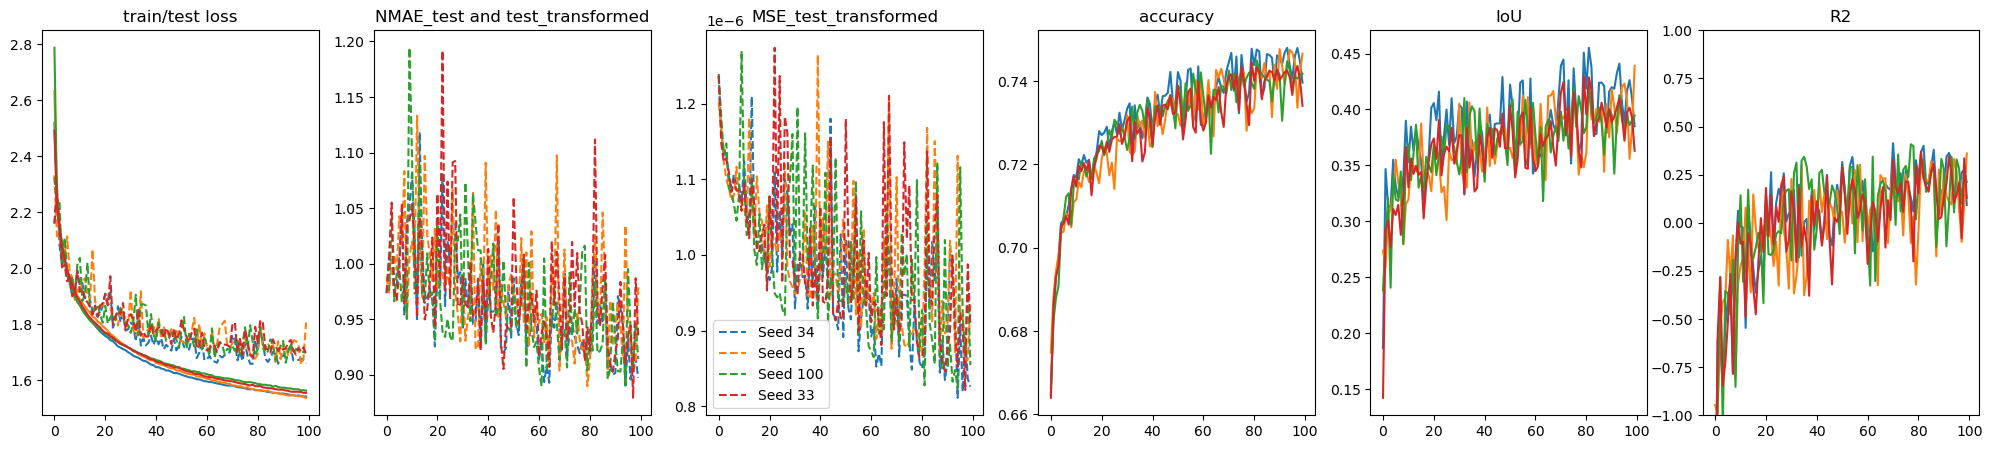

In [61]:
models_to_plot = [loss_weiB, loss_weiC5, loss_weiC100, loss_weiC33]
fig, ax = plt.subplots(1,6, figsize = (25,5))
for mod in models_to_plot:
    if "train" in list(mod.keys()):
        p, = ax[0].plot(mod["train"][:100])
        ax[0].plot(mod["test"][:100], "--", c=p.get_color()) 
    #if "NMAE_test" in list(mod.keys()):
    #    ax[1].plot(abs(np.array(mod["NMAE_test"])), c=p.get_color())  
    if "NMAE_test_transformed" in list(mod.keys()):
        ax[1].plot(abs(np.array(mod["NMAE_test_transformed"]))[:100], "--", c=p.get_color())       
    if "MSE_test_transformed" in list(mod.keys()):
        ax[2].plot(abs(np.array(mod["MSE_test_transformed"]))[:100], "--", c=p.get_color(), label=mod["name"])    
    if "accuracy" in list(mod.keys()):
        ax[3].plot(abs(np.array(mod["accuracy"]))[:100], c=p.get_color())    
    if "IoU" in list(mod.keys()):
        ax[4].plot(abs(np.array(mod["IoU"]))[:100], c=p.get_color())   
    if "flux_uniform" in list(mod.keys()):
        ax[5].plot(mod["flux_uniform"]["R2"][:100], c=p.get_color())   
    

ax[0].set_title("train/test loss")
ax[1].set_title("NMAE_test and test_transformed")
ax[2].set_title("MSE_test_transformed")
ax[3].set_title("accuracy")
ax[4].set_title("IoU")
ax[5].set_title("R2")
ax[5].set_ybound(-1,1)
ax[2].legend()

## Aggregating: Plot mean + SD for training metrics

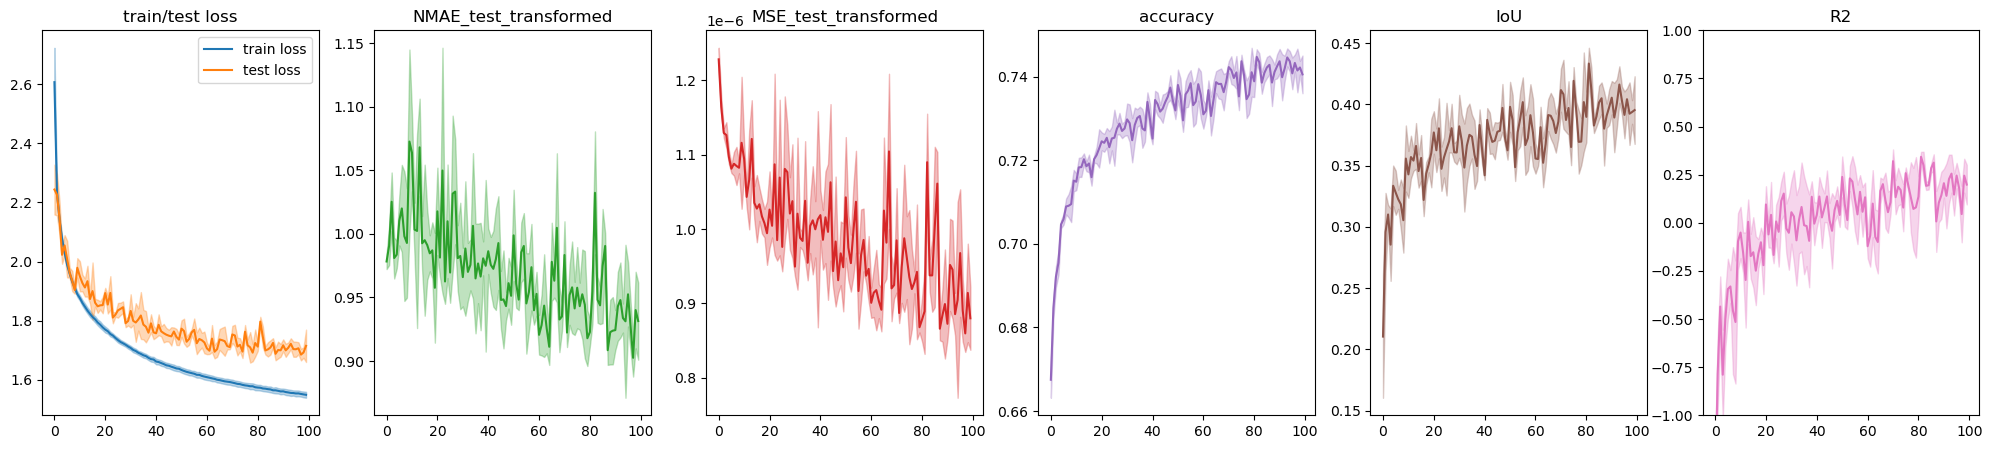

Saved model_training_uncertainty.png


In [62]:
colours = plt.cm.tab10.colors

# Create a new figure for uncertainty plots
fig2, ax2 = plt.subplots(1,6, figsize=(25,5))

plot_mean_with_uncertainty(ax2[0], models_to_plot, "train", label="train loss", color=colours[0])
plot_mean_with_uncertainty(ax2[0], models_to_plot, "test", label="test loss", color=colours[1])
ax2[0].set_title("train/test loss")
ax2[0].legend()

plot_mean_with_uncertainty(ax2[1], models_to_plot, "NMAE_test_transformed", label="NMAE", color=colours[2])
ax2[1].set_title("NMAE_test_transformed")

plot_mean_with_uncertainty(ax2[2], models_to_plot, "MSE_test_transformed", label="MSE", color=colours[3])
ax2[2].set_title("MSE_test_transformed")

plot_mean_with_uncertainty(ax2[3], models_to_plot, "accuracy", label="accuracy", color=colours[4])
ax2[3].set_title("accuracy")

plot_mean_with_uncertainty(ax2[4], models_to_plot, "IoU", label="IoU", color=colours[5])
ax2[4].set_title("IoU")

plot_mean_with_uncertainty(ax2[5], models_to_plot, "flux_uniform", label="R2", color=colours[6])
ax2[5].set_title("R2")
ax2[5].set_ybound(-1, 1)

plt.savefig(save_path("model_training_uncertainty.png"))
plt.show()
plt.close()
print(f"Saved model_training_uncertainty.png")



# 2. Footprints

loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_B/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed5/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed100/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed33/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


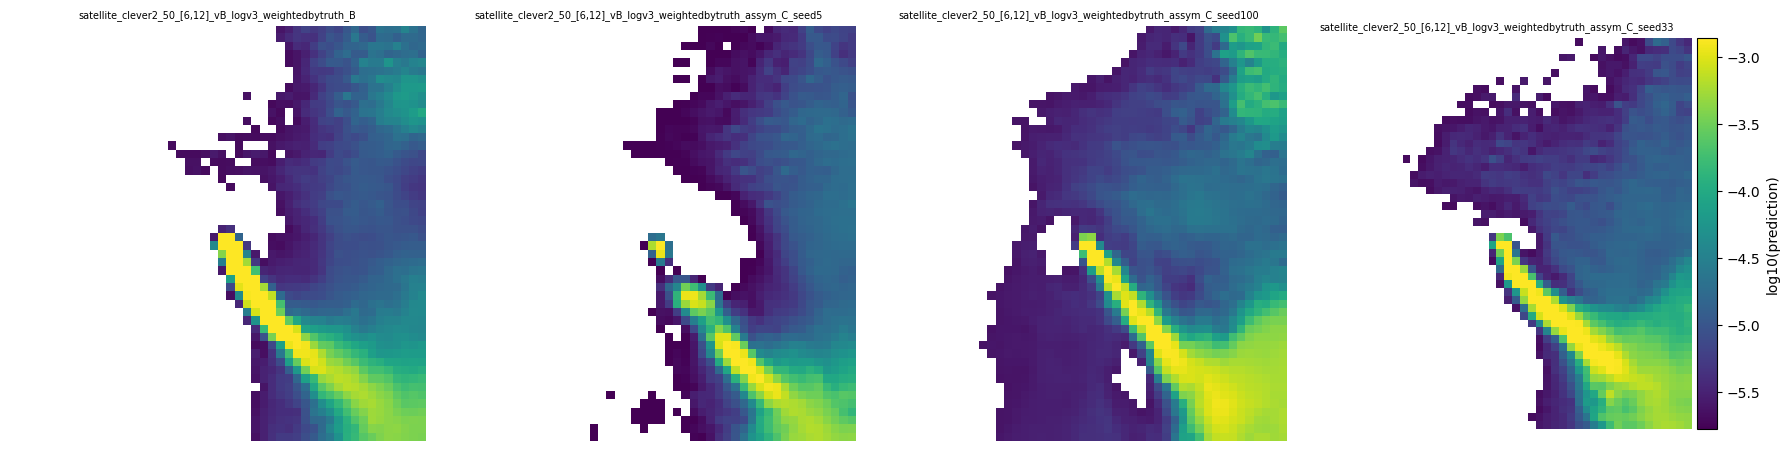

In [65]:
fig, axes = plt.subplots(1, len(model_names), figsize=(4.5 * len(model_names), 4.5))

models = []
data_logs = []

# ---- Load once, compute robust global vmin/vmax across ALL models ----
for name in model_names:
    mod = ModelEv(
        name,
        size=50,
        validation_set="0[1-3]",
        test_set="*",
        val_year="2016",
        test_year="2016",
        check_validation_overlap=True,
        path_to_files="/group/chemistry/acrg/ef17148/trained_satellite_models/"
    )
    mod.get_adjusted_models(which="thr_only")

    arr = np.asarray(mod.preds_test.thr[single_time_step])

    # Avoid -inf from log10(0) or <=0 values by masking them out
    arr_log = np.where(arr > 0, np.log10(arr), np.nan)

    models.append((name, mod))
    data_logs.append(arr_log)

# robust limits (e.g., 2nd–98th percentile) over ALL models, ignoring NaNs
stacked = np.concatenate([d[np.isfinite(d)].ravel() for d in data_logs if np.isfinite(d).any()])
vmin = np.nanpercentile(stacked, 2)
vmax = np.nanpercentile(stacked, 98)

# ---- Plot ----
last_im = None
for i, ((name, _), data_log) in enumerate(zip(models, data_logs)):
    ax = axes[i] if len(model_names) > 1 else axes
    last_im = ax.imshow(data_log, vmin=vmin, vmax=vmax)
    ax.set_title(name, fontsize=7, wrap=False) 
    ax.axis("off")

divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.05)
cb = fig.colorbar(last_im, cax=cax)
cb.set_label("log10(prediction)")

plt.tight_layout()
plt.savefig(save_path("fp_predictions_all_models_one_timepoint.png"))
plt.show()
plt.close()

In [66]:
# Build a list of DataArrays and a matching list of seed names
thr_list = []
seed_names = []

for name, mod in models:
    thr_list.append(xr.DataArray(mod.preds_test.thr, dims=["time", "lat", "lon"]))
    seed_names.append(name)

# Concatenate along a new "seed" dimension, labelled by model names
thr_preds = xr.concat(
    thr_list,
    dim=xr.DataArray(seed_names, dims=["seed"], name="seed")
)

# Ground truth from the first model
fp = xr.DataArray(models[0][1].preds_test.fp, dims=["time", "lat", "lon"])

## Basic statistics

### Per timestep

In [67]:
save_file_summary = save_path("uncertainty_summary_statistics.nc")
if os.path.exists(save_file_summary):
    print(f"Loading cached stats arrays from {save_file_summary}...")
    # Reopen the dataset
    summary_ds = xr.open_dataset(save_file_summary)

    # Extract variables as NumPy arrays
    mean_pred = summary_ds["mean_prediction"]
    std_pred = summary_ds["std_deviation"]
    cv_pred = summary_ds["coefficient_of_variation"]
    p5 = summary_ds["percentile_5"]
    p95 = summary_ds["percentile_95"]
    range_90 = summary_ds["range_90"]
    disagreement_mask = summary_ds["disagreement_zone"]

else:
    mean_pred = thr_preds.mean(dim="seed")
    std_pred = thr_preds.std(dim="seed")
    cv_pred = std_pred / (mean_pred + epsilon)
    q_vals = thr_preds.quantile([0.05, 0.95], dim="seed")
    p5 = q_vals.sel(quantile=0.05).drop_vars("quantile")
    p95 = q_vals.sel(quantile=0.95).drop_vars("quantile")
    range_90 = p95 - p5

    # Prediction disagreement zone (binary mask)
    disagreement_mask = (range_90 > disagreement_threshold)

    # Save summary statistics to NetCDF
    summary_ds = xr.Dataset({
        "mean_prediction": mean_pred,
        "std_deviation": std_pred,
        "coefficient_of_variation": cv_pred,
        "percentile_5": p5,
        "percentile_95": p95,
        "range_90": range_90,
        "disagreement_zone": disagreement_mask.astype("int")
    })
    summary_ds.to_netcdf(save_file_summary)
    print("Saved uncertainty_summary_statistics.nc")

Loading cached stats arrays from uncertainty/summary_outputs/uncertainty_summary_statistics.nc...


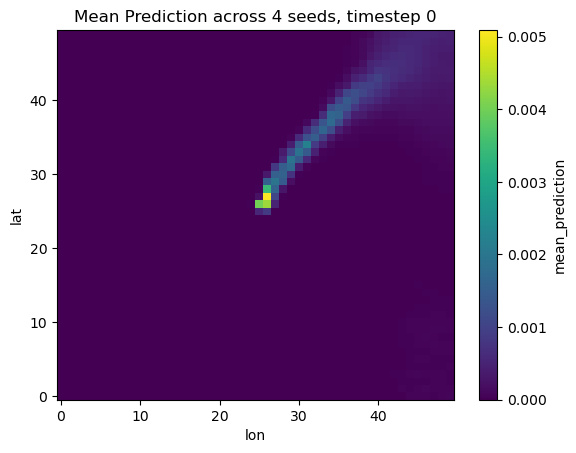

Saved Mean Prediction across 4 seeds, timestep 0.png


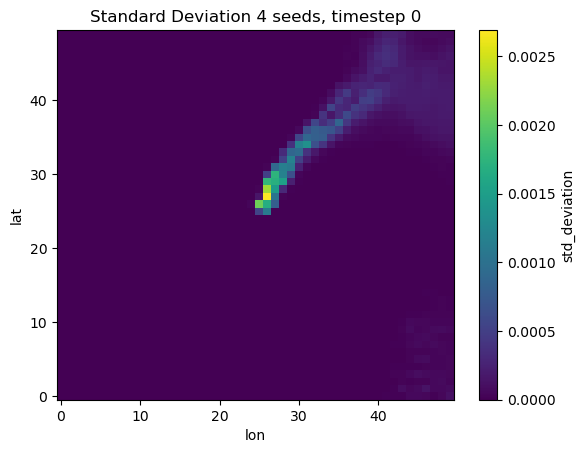

Saved Standard Deviation 4 seeds, timestep 0.png


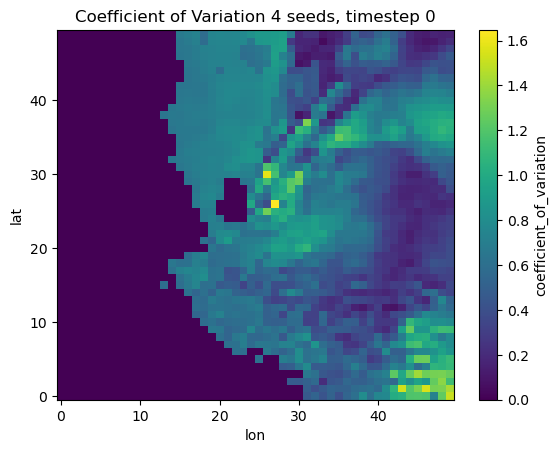

Saved Coefficient of Variation 4 seeds, timestep 0.png


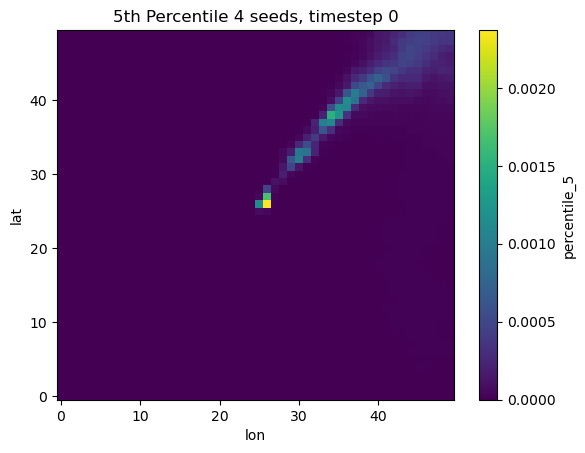

Saved 5th Percentile 4 seeds, timestep 0.png


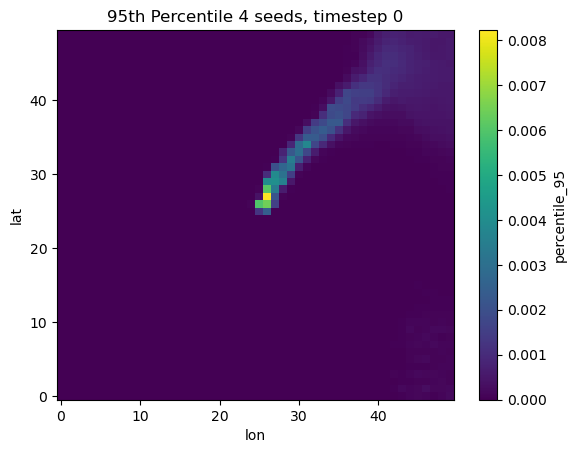

Saved 95th Percentile 4 seeds, timestep 0.png


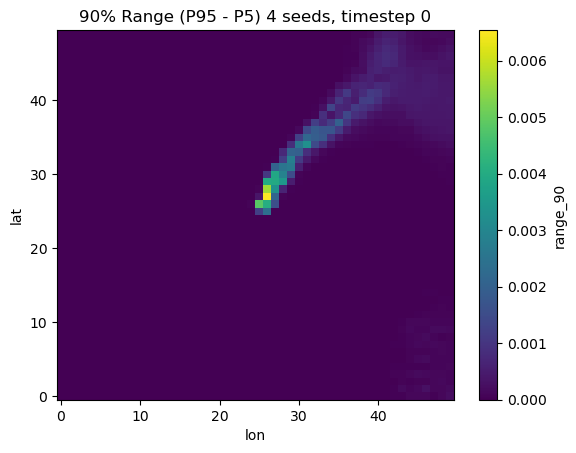

Saved 90% Range (P95 - P5) 4 seeds, timestep 0.png


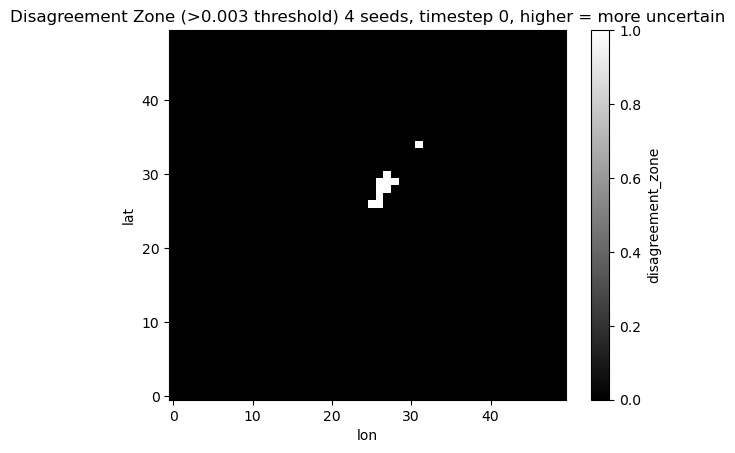

Saved Disagreement Zone (>0.003 threshold) 4 seeds, timestep 0, higher = more uncertain.png


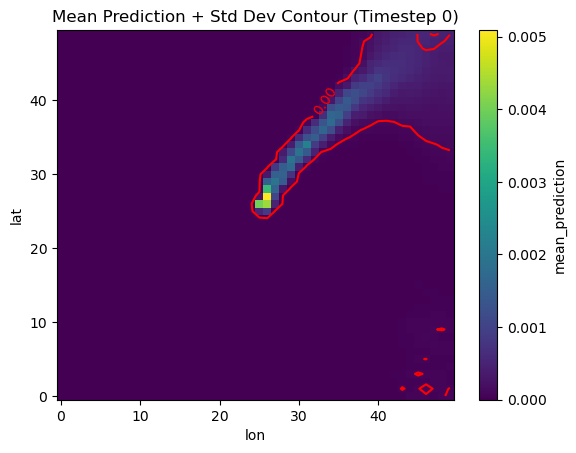

Saved mean_with_std_contour.png


In [68]:
num_models = len(models)

# Plot basic metrics
plots = {
    f"Mean Prediction across {num_models} seeds, timestep {single_time_step}": summary_ds["mean_prediction"],
    f"Standard Deviation {num_models} seeds, timestep {single_time_step}": summary_ds["std_deviation"],
    f"Coefficient of Variation {num_models} seeds, timestep {single_time_step}" : summary_ds["coefficient_of_variation"],
    f"5th Percentile {num_models} seeds, timestep {single_time_step}": summary_ds["percentile_5"],
    f"95th Percentile {num_models} seeds, timestep {single_time_step}": summary_ds["percentile_95"],
    f"90% Range (P95 - P5) {num_models} seeds, timestep {single_time_step}": summary_ds["range_90"],
    f"Disagreement Zone (>{disagreement_threshold} threshold) {num_models} seeds, timestep {single_time_step}, higher = more uncertain": disagreement_mask
}

for name, data in plots.items():
    plt.figure()
    if "time" in data.dims:
        data = data.isel(time=single_time_step)
    data.plot(cmap="viridis" if "Zone" not in name else "gray")
    plt.title(name)
    plt.savefig(save_path(name.replace(" ", "_").lower() + ".png"))
    plt.show()
    plt.close()
    print(f"Saved {name}.png")

# Uncertainty-weighted visualisation (mean + contour of standard deviation)
plt.figure()
mean_pred.isel(time=0).plot(cmap="viridis")  # reduce to 2D
cs = plt.contour(std_pred.isel(time=time_steps[0]), levels=[std_pred.mean().item()], colors="red")
plt.clabel(cs, fmt="%.2f", colors="red")
plt.title("Mean Prediction + Std Dev Contour (Timestep 0)")
plt.savefig(save_path("mean_with_std_contour.png"))
plt.show()
plt.close()
print("Saved mean_with_std_contour.png")



# Histograms showing distributions of uncertainty metrics
histograms = {
    "Standard Deviation": std_pred.values.flatten(),
    "Coefficient of Variation": cv_pred.values.flatten(),
    "90% Prediction Range": range_90.values.flatten()
}


#### --- Could rethreshold eg mean prediction?

### Compute errors

In [69]:
abs_error = abs(mean_pred - fp)

error_vs_uncertainty = xr.Dataset({
    "abs_error": abs_error,
    "std_deviation": std_pred
})
error_vs_uncertainty.to_netcdf(save_path("error_vs_uncertainty.nc"))
print("Saved error_vs_uncertainty.nc")
# Scatter correlation

err_flat = abs_error.values.flatten()
unc_flat = std_pred.values.flatten()

valid = ~np.isnan(err_flat) & ~np.isnan(unc_flat)
corr, pval = pearsonr(unc_flat[valid], err_flat[valid])
print(f"Pearson r between uncertainty and abs error: {corr:.3f} (p={pval:.2g})")


Saved error_vs_uncertainty.nc
Pearson r between uncertainty and abs error: 0.675 (p=0)


## Distributions

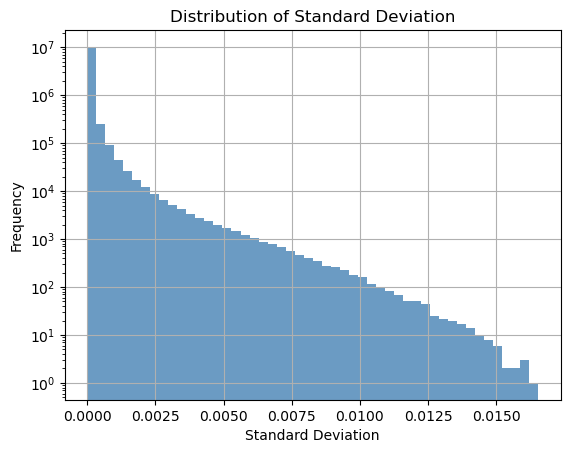

Saved hist_standard_deviation.png


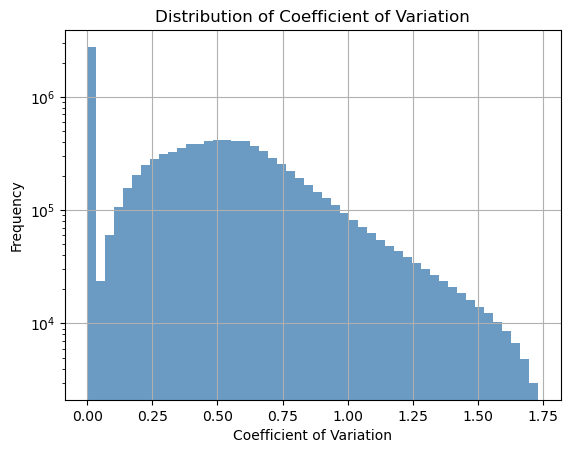

Saved hist_coefficient_of_variation.png


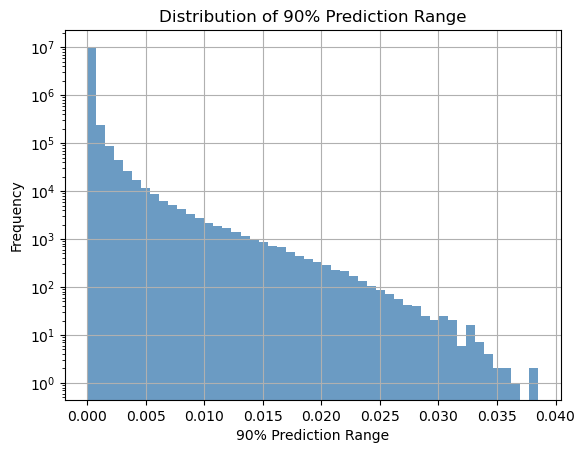

Saved hist_90%_prediction_range.png


In [70]:
# Histograms showing distributions of uncertainty metrics, aggregated over time
histograms = {
    "Standard Deviation": summary_ds["std_deviation"].values.flatten(),
    "Coefficient of Variation": summary_ds["coefficient_of_variation"].values.flatten(),
    "90% Prediction Range": summary_ds["range_90"].values.flatten()
}

for name, values in histograms.items():
    plt.figure()
    plt.hist(values, bins=50, color="steelblue", alpha=0.8)
    plt.yscale("log")
    plt.title(f"Distribution of {name}")
    plt.xlabel(name)
    plt.ylabel("Frequency")
    plt.grid(True)
    filename = f"hist_{name.lower().replace(' ', '_')}.png"
    plt.savefig(save_path(filename))
    plt.show()
    plt.close()
    print(f"Saved {filename}")

## Plots vs true fps

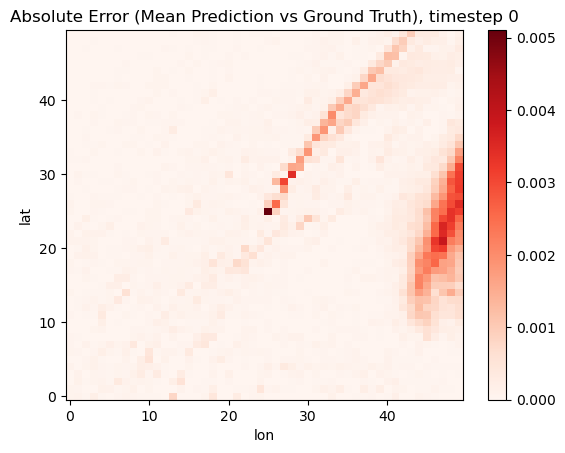

Saved abs_error.png


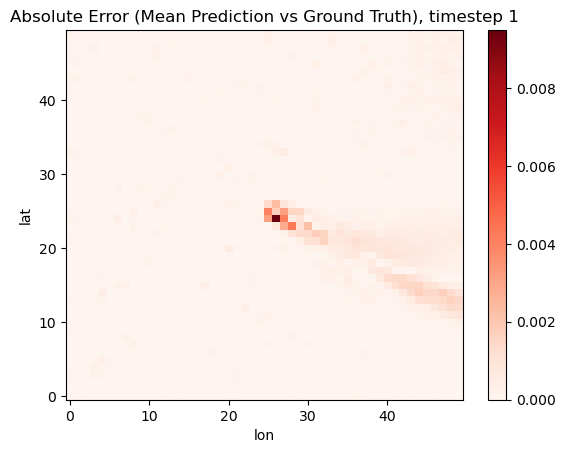

Saved abs_error.png


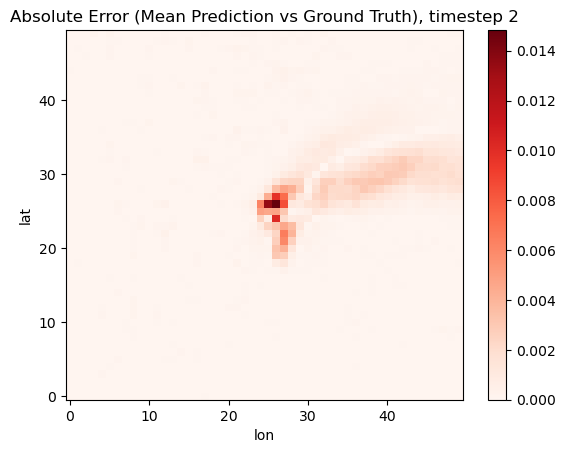

Saved abs_error.png


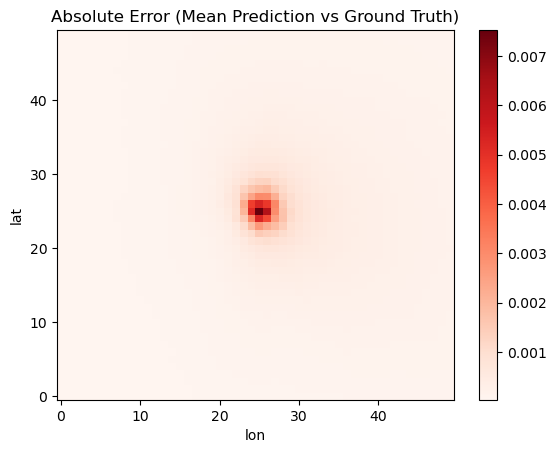

Saved abs_error.png


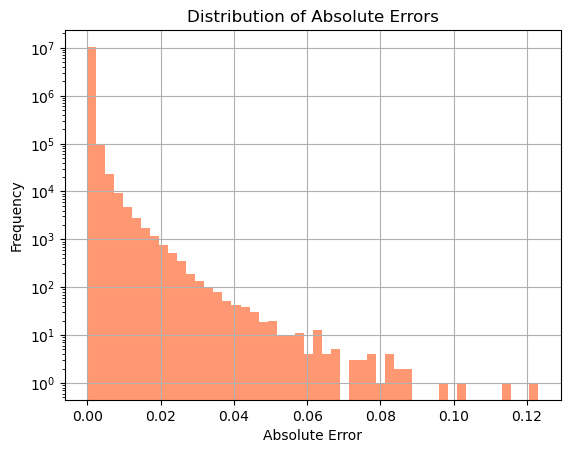

Saved hist_abs_error.png
Pearson correlation between uncertainty and error: 0.675 (p=0)


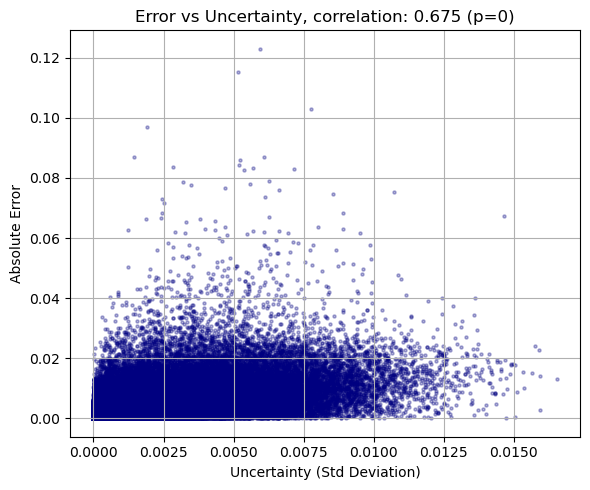

Saved scatter_error_vs_uncertainty.png


In [71]:
# Plot absolute error

for time_step in time_steps:
    plt.figure()
    abs_error.isel(time=time_step).plot.imshow(cmap="Reds")
    plt.title(f"Absolute Error (Mean Prediction vs Ground Truth), timestep {time_step}")
    plt.savefig(save_path(f"abs_error_time_{time_step}.png"))
    plt.show()
    plt.close()
    print("Saved abs_error.png")

# And average error
plt.figure()
abs_error.mean(dim="time").plot.imshow(cmap="Reds")
plt.title("Absolute Error (Mean Prediction vs Ground Truth)")
plt.savefig(save_path(f"abs_error_average.png"))
plt.show()
plt.close()
print("Saved abs_error.png")

# Histogram of absolute error
plt.figure()
plt.hist(abs_error.values.flatten(), bins=50, color="coral", alpha=0.8)
plt.title("Distribution of Absolute Errors")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.yscale("log")
plt.grid(True)
plt.savefig(save_path("hist_abs_error.png"))
plt.show()
plt.close()
print("Saved hist_abs_error.png")

# Error vs uncertainty
# Flatten to 1D arrays
error_values = abs_error.values.flatten()
uncertainty_values = std_pred.values.flatten()

# Filter out NaNs (e.g. ocean regions / cropped regions if applicable)
valid = ~np.isnan(error_values) & ~np.isnan(uncertainty_values)
error_values = error_values[valid]
uncertainty_values = uncertainty_values[valid]

corr, p = pearsonr(uncertainty_values, error_values)
print(f"Pearson correlation between uncertainty and error: {corr:.3f} (p={p:.3g})")

# Create scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(uncertainty_values, error_values, alpha=0.3, s=5, c="navy")
plt.xlabel("Uncertainty (Std Deviation)")
plt.ylabel("Absolute Error")
plt.title(f"Error vs Uncertainty, correlation: {corr:.3f} (p={p:.3g})")
plt.grid(True)
plt.tight_layout()
plt.savefig(save_path("scatter_error_vs_uncertainty.png"))
plt.show()
plt.close()
print("Saved scatter_error_vs_uncertainty.png")




## Consider both spatial and temporal components

In [72]:
disagreement_freq = disagreement_mask.mean(dim="time")  # values between 0 and 1

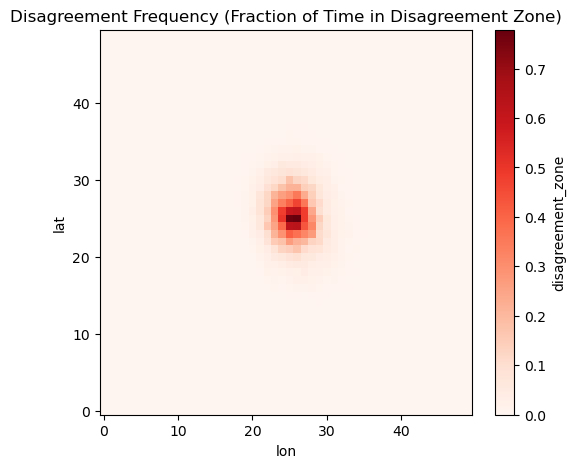

Saved disagreement_zone_frequency.png


In [73]:
plt.figure(figsize=(6, 5))
disagreement_freq.plot(cmap="Reds")
plt.title("Disagreement Frequency (Fraction of Time in Disagreement Zone)")
plt.savefig(save_path("disagreement_zone_frequency.png"))
plt.show()
plt.close()
print("Saved disagreement_zone_frequency.png")

## Temporal uncertainty

### Uncertainty of ensemble

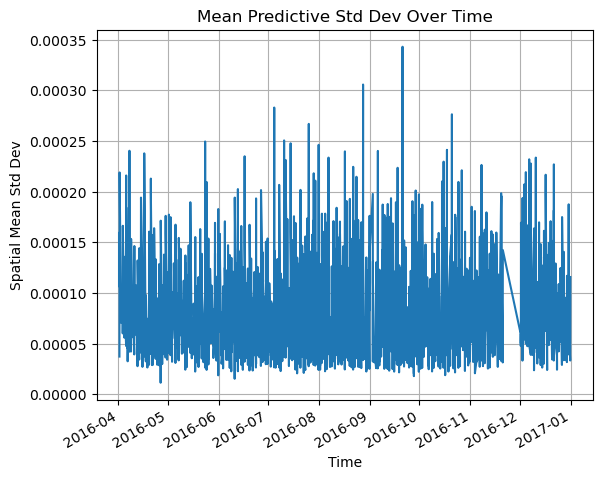

In [74]:
temporal_uncertainty = std_pred.mean(dim=("lat", "lon"))

plt.figure()
temporal_uncertainty.plot()
plt.title("Mean Predictive Std Dev Over Time")
plt.xlabel("Time")
plt.ylabel("Spatial Mean Std Dev")
plt.grid(True)
plt.savefig(save_path("temporal_std_dev.png"))
plt.show()
plt.close()


### And mean MAE of ensemble compared to true fps

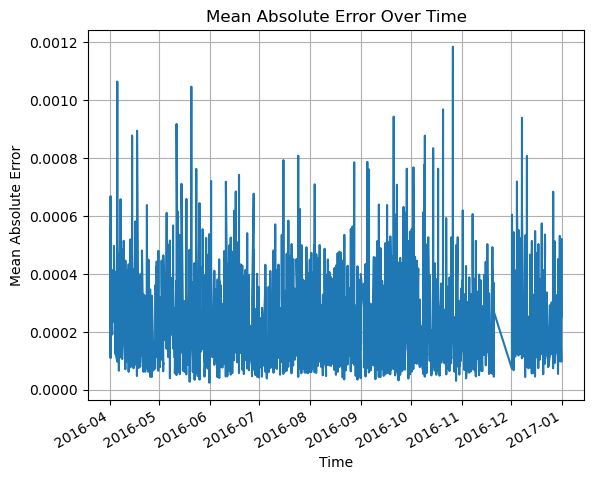

In [75]:
# Mean absolute error across space at each time step
temporal_mae = abs_error.mean(dim=("lat", "lon"))

# Plot
plt.figure()
temporal_mae.plot()
plt.title("Mean Absolute Error Over Time")
plt.xlabel("Time")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.savefig(save_path("temporal_mae.png"))
plt.show()
plt.close()

### Correlation Between Uncertainty and Error Over Time

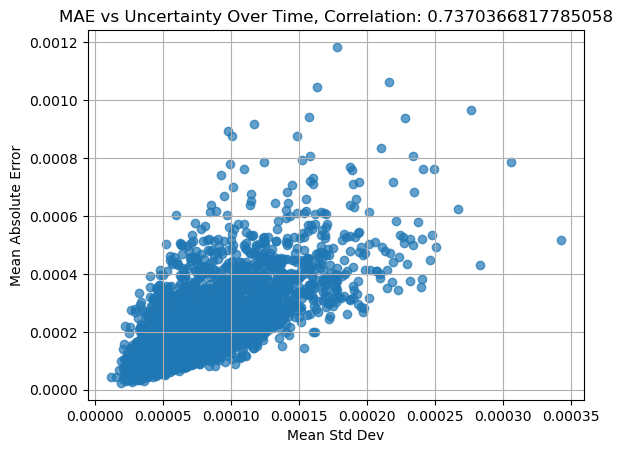

In [ ]:
mae_over_time = abs_error.mean(dim=("lat", "lon"))
std_over_time = std_pred.mean(dim=("lat", "lon"))
corr_time = np.corrcoef(mae_over_time, std_over_time)[0, 1]

plt.figure()
plt.scatter(std_over_time, mae_over_time, alpha=0.7)
plt.title(f"MAE vs Uncertainty Over Time, Correlation: {corr_time}")
plt.xlabel("Mean Std Dev")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.savefig(save_path("mae_error_vs_uncertainty_time.png"))
plt.show()
plt.close()

### --- Run also for MSE and NMAE

## Spatio-Temporal Consistency

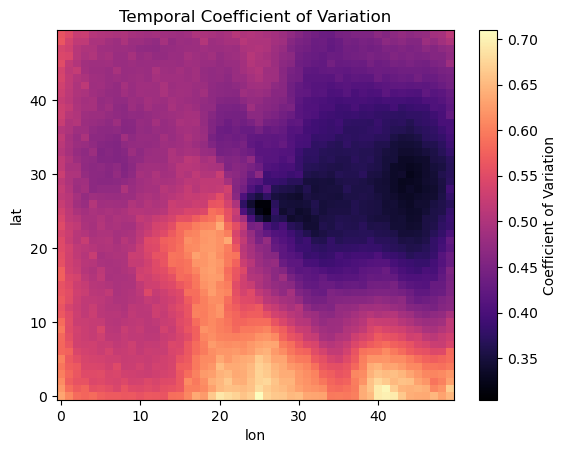

In [ ]:
# Temporal standard deviation of uncertainty at each location
uncertainty_variability = std_pred.mean(dim="time")/ mean_pred.mean(dim="time")  # Coefficient of Variation across time
#1408N
plt.figure()
p = uncertainty_variability.plot(cmap="magma")
p.colorbar.set_label("Coefficient of Variation")
plt.title("Temporal Coefficient of Variation")
plt.savefig(save_path("temporal_Coefficient_of_Variation_uncertainty.png"))
plt.show()
plt.close()

### Animated uncertainty visulation

In [37]:
# These take a long time to run so I suggest not running them unless you want to see the animations
#animate_dataarray(mean_pred, "Mean Prediction", "mean_prediction.gif", cmap="viridis", save_dir=summary_dir)
#animate_dataarray(std_pred[0:100], "Standard Deviation[0:100]", "std_dev_over_time[0:100].gif", cmap="magma", save_dir=summary_dir)
#animate_dataarray(cv_pred[0:100], "Coefficient of Variation[0:100]", "cv_over_time[0:100].gif", cmap="cividis", save_dir=summary_dir)


# 3. Mole fractions

## Mole fractions using default uniform flux field, ie summing over the footprints

In [33]:
pred_mole_fractions, true_mole_fractions = get_all_mole_fractions(flux_type = "uniform")

Loading cached mole fraction arrays from mole_fractions.npz...
Loaded shapes: pred=(4, 4243), true=(4, 4243)


### Plot for all models

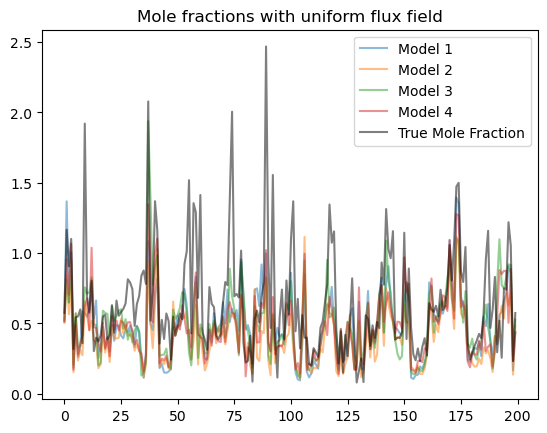

In [36]:
plot_mole_fraction(pred_mole_fractions, true_mole_fractions)

### Compute stats

In [37]:
mean_mole_fraction, std_mole_fraction, mean_true_mole_fraction, normalised_mean_mole_fraction, normalised_std_mole_fraction  = compute_flux_stats(pred_mole_fractions, true_mole_fractions)

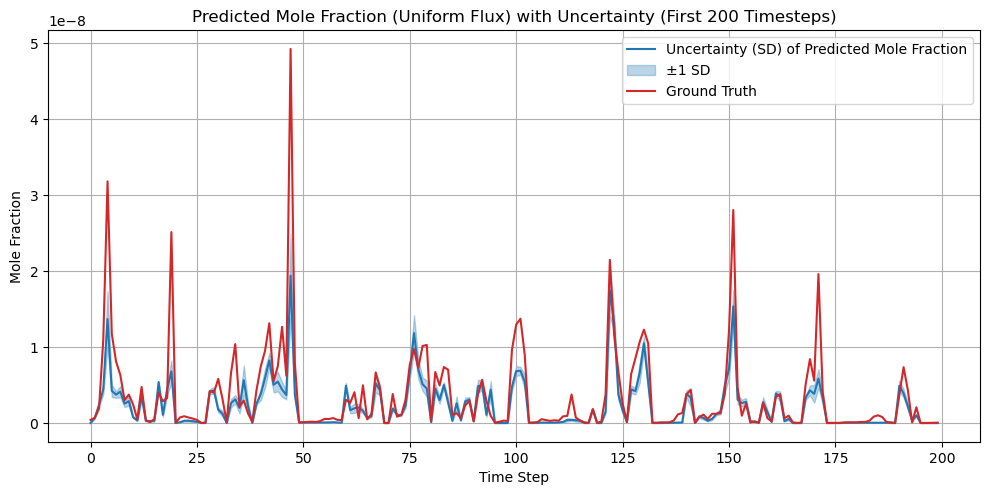

In [89]:
plot_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, plot="mean")

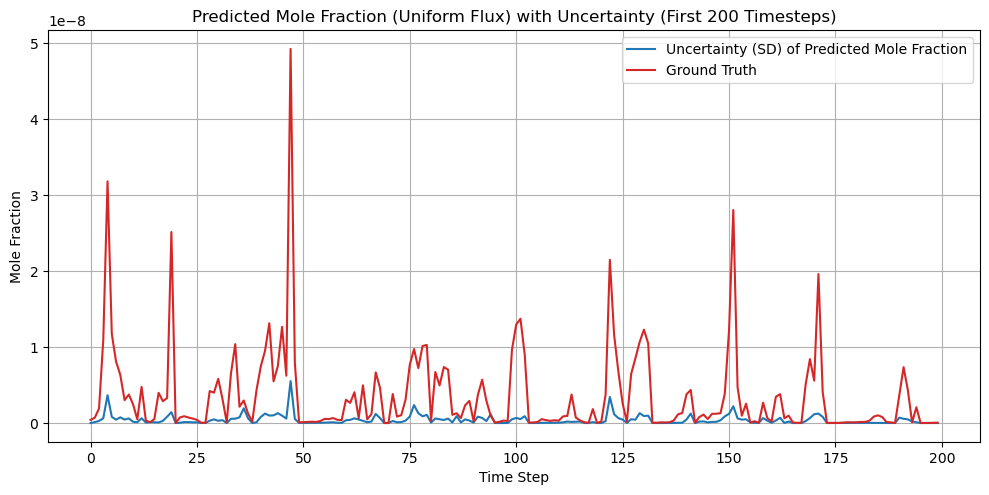

In [92]:
plot_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, plot="SD")

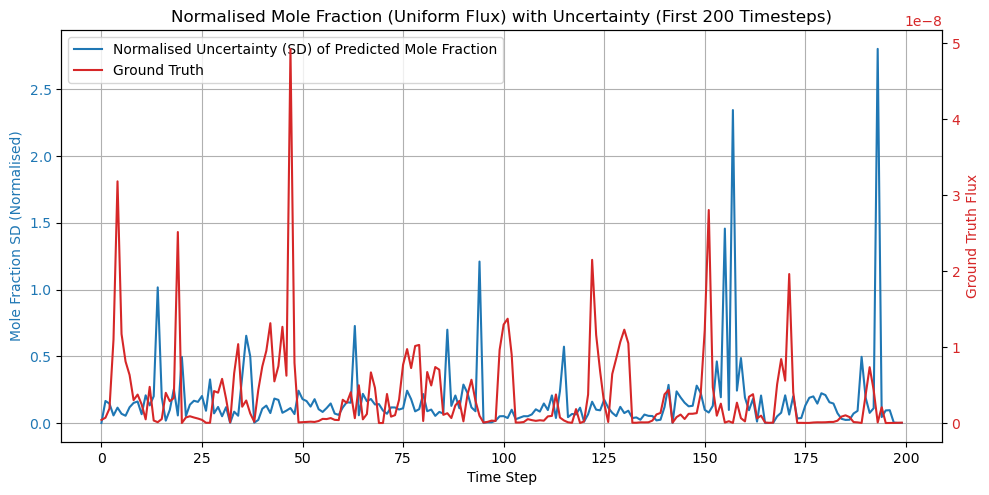

In [86]:
plot_normalised_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions)

### Now find the extreme time steps with the largest uncertainty, and the lowest

In [90]:
highest_uncertainty_indices, lowest_uncertainty_indices = find_extreme_mole_fraction_uncertainties(std_mole_fraction)

--- 10 highest uncertainties: ---
Time step 2476: std = 0.5780
Time step 2924: std = 0.5520
Time step 1764: std = 0.4496
Time step 3414: std = 0.4292
Time step 1339: std = 0.4040
Time step 727: std = 0.4026
Time step 93: std = 0.3868
Time step 3946: std = 0.3851
Time step 1434: std = 0.3839
Time step 2399: std = 0.3820
--- 10 lowest uncertainties: ---
Time step 250: std = 0.0032
Time step 3141: std = 0.0034
Time step 3984: std = 0.0036
Time step 1644: std = 0.0037
Time step 1822: std = 0.0038
Time step 3966: std = 0.0044
Time step 2897: std = 0.0046
Time step 2514: std = 0.0051
Time step 627: std = 0.0053
Time step 1969: std = 0.0061


--- 5 highest uncertainties: ---
Time step 2476: std = 0.5780
Time step 2924: std = 0.5520
Time step 1764: std = 0.4496
Time step 3414: std = 0.4292
Time step 1339: std = 0.4040
--- 5 lowest uncertainties: ---
Time step 250: std = 0.0032
Time step 3141: std = 0.0034
Time step 3984: std = 0.0036
Time step 1644: std = 0.0037
Time step 1822: std = 0.0038


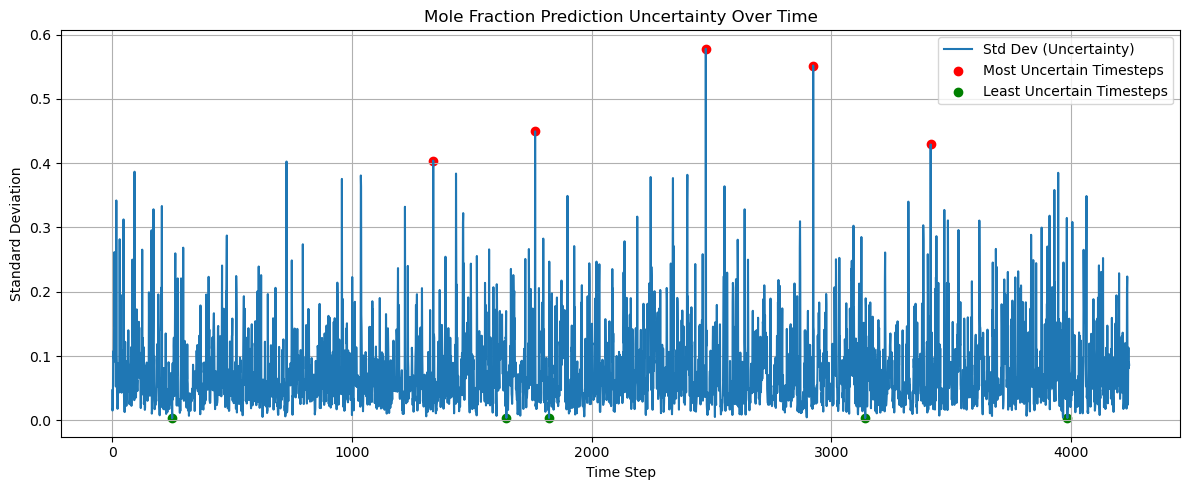

In [91]:
plot_extreme_mole_fraction_uncertainties(std_mole_fraction, 5)

## Now load and cut the actual fluxes to get realistic above-baseline mole fractions

In [12]:
flux_type = "actual"

In [42]:
pred_mole_fractions, true_mole_fractions = get_all_mole_fractions(flux_type = flux_type)

Loading cached mole fraction arrays from mole_fractions_above_baseline.npz...
Loaded shapes: pred=(4, 4243), true=(4, 4243)


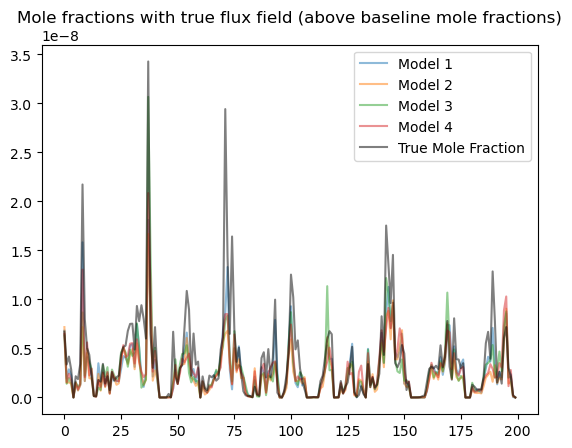

In [43]:
plot_mole_fractions(pred_mole_fractions, true_mole_fractions, flux_type=flux_type)

In [45]:
# compute stats
mean_mole_fractions, std_mole_fractions, mean_true_mole_fractions, normalised_mean_mole_fractions, normalised_std_mole_fractions = compute_mole_fraction_stats(pred_mole_fractions, true_mole_fractions)

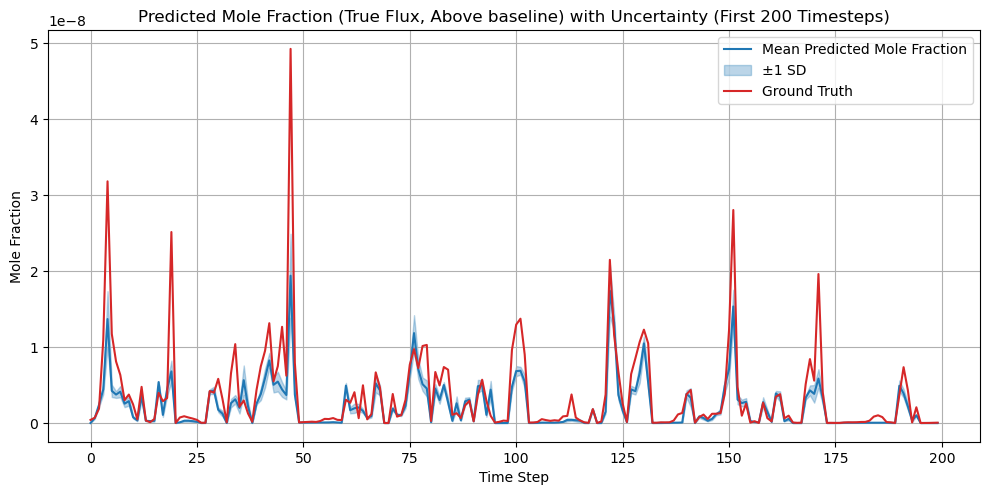

In [46]:
# plot
plot_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, flux_type=flux_type)

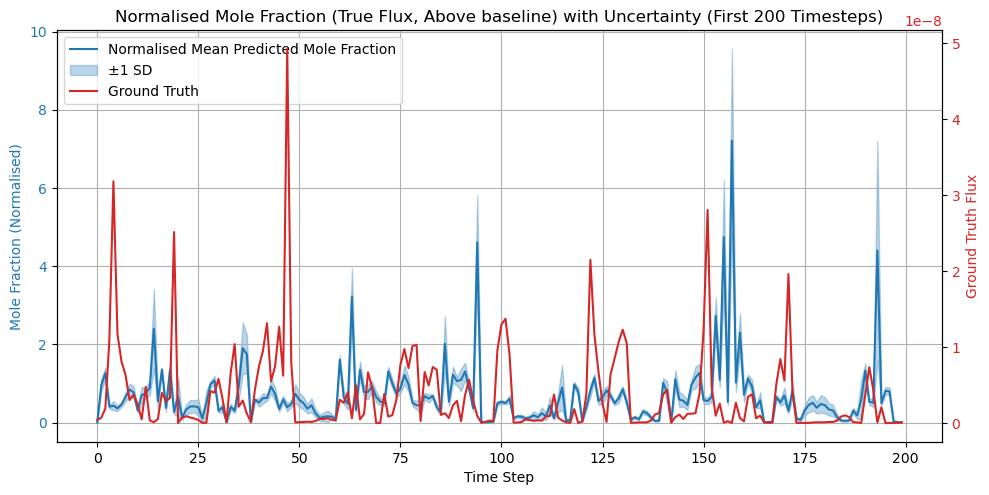

In [47]:
plot_normalised_mole_fraction_uncertainty(pred_mole_fractions, true_mole_fractions, flux_type=flux_type)

In [48]:
highest_uncertainty_indices, lowest_uncertainty_indices = find_extreme_mole_fraction_uncertainties(std_mole_fraction)

--- 10 highest uncertainties: ---
Time step 2476: std = 0.5780
Time step 2924: std = 0.5520
Time step 1764: std = 0.4496
Time step 3414: std = 0.4292
Time step 1339: std = 0.4040
Time step 727: std = 0.4026
Time step 93: std = 0.3868
Time step 3946: std = 0.3851
Time step 1434: std = 0.3839
Time step 2399: std = 0.3820
--- 10 lowest uncertainties: ---
Time step 250: std = 0.0032
Time step 3141: std = 0.0034
Time step 3984: std = 0.0036
Time step 1644: std = 0.0037
Time step 1822: std = 0.0038
Time step 3966: std = 0.0044
Time step 2897: std = 0.0046
Time step 2514: std = 0.0051
Time step 627: std = 0.0053
Time step 1969: std = 0.0061


--- 5 highest uncertainties: ---
Time step 827: std = 2.6212
Time step 1390: std = 2.2553
Time step 2022: std = 2.2419
Time step 3094: std = 2.0008
Time step 2375: std = 1.7785
--- 5 lowest uncertainties: ---
Time step 2514: std = 0.0057
Time step 3141: std = 0.0068
Time step 1145: std = 0.0090
Time step 544: std = 0.0092
Time step 1691: std = 0.0094


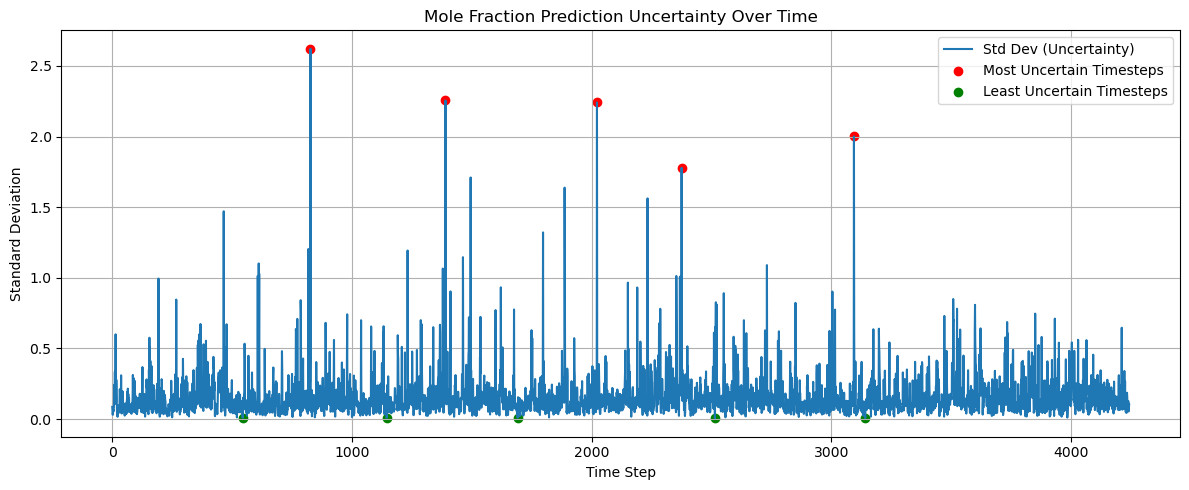

In [49]:
plot_extreme_mole_fraction_uncertainties(normalised_std_mole_fraction, 5)

----

In [171]:
# loads the brazil map of fluxes
brazil_fluxes = load_default_brazil_emissions()

# load the true footprints to use the release_lat and release_lon,
# and select the same timepoints as the testing set
true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
true_fps = true_fps.sel(time=mod.preds_test.time)

cut_flux = cut_emissions_data(brazil_fluxes, true_fps, 50)
cut_flux = cut_flux.transpose([2,0,1])
# now cut_flux is in the same shape as mod.pred_fluxes["thr"], so we can plot it
mod.get_fluxes(cut_flux)

USING NO UNITS TRANSFORM on the fluxes! this may have changed


## Compute stats

## Now find the 10 time steps with the largest uncertainty, and the lowest

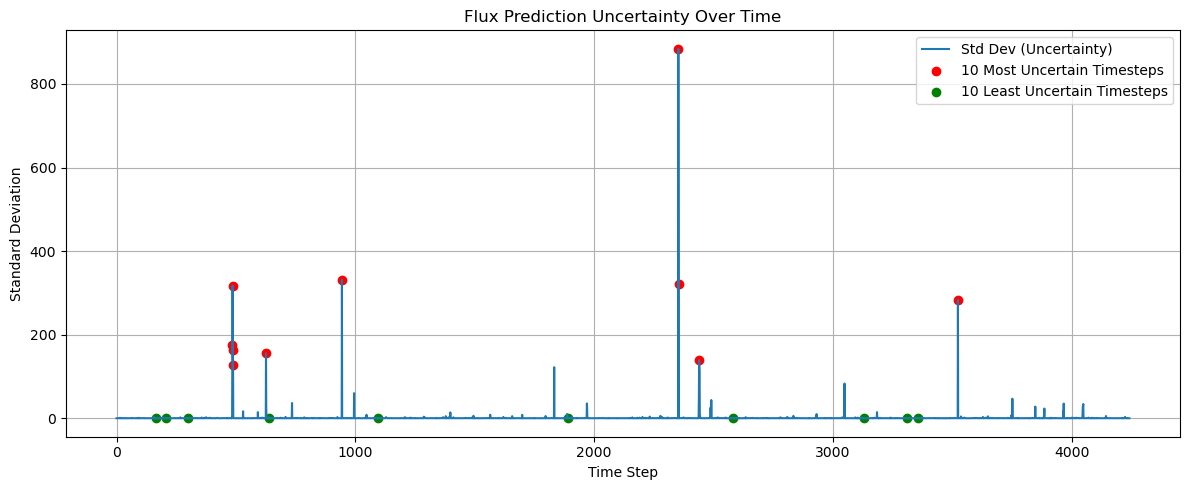

In [26]:
time = np.arange(len(normalised_std_flux))
plt.figure(figsize=(12, 5))
plt.plot(time, normalised_std_flux, label="Std Dev (Uncertainty)", color="tab:blue")

# Highlight top uncertain timesteps
plt.scatter(highest_uncertainty_indices, normalised_std_flux[highest_uncertainty_indices], color="red", label=f"{top_n} Most Uncertain Timesteps")
plt.scatter(lowest_uncertainty_indices, normalised_std_flux[lowest_uncertainty_indices], color="green", label=f"{top_n} Least Uncertain Timesteps")


plt.title("Flux Prediction Uncertainty Over Time")
plt.xlabel("Time Step")
plt.ylabel("Standard Deviation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(save_path("flux_timeseries_with_high_low_uncertainty_true.png"))
plt.show()

# 1. Time - seasonal analysis, starting with mole fractions

# 2. Space - Disaggregated map of errors

[-60.981 -60.747 -60.513 -60.279 -60.045 -59.811 -59.577 -59.343 -59.109
 -58.875 -58.641 -58.407 -58.173 -57.939 -57.705 -57.471 -57.237 -57.003
 -56.769 -56.535 -56.301 -56.067 -55.833 -55.599 -55.365 -55.131 -54.897
 -54.663 -54.429 -54.195 -53.961 -53.727 -53.493 -53.259 -53.025 -52.791
 -52.557 -52.323 -52.089 -51.855 -51.621 -51.387 -51.153 -50.919 -50.685
 -50.451 -50.217 -49.983 -49.749 -49.515 -49.281 -49.047 -48.813 -48.579
 -48.345 -48.111 -47.877 -47.643 -47.409 -47.175 -46.941 -46.707 -46.473
 -46.239 -46.005 -45.771 -45.537 -45.303 -45.069 -44.835 -44.601 -44.367
 -44.133 -43.899 -43.665 -43.431 -43.197 -42.963 -42.729 -42.495 -42.261
 -42.027 -41.793 -41.559 -41.325 -41.091 -40.857 -40.623 -40.389 -40.155
 -39.921 -39.687 -39.453 -39.219 -38.985 -38.751 -38.517 -38.283 -38.049
 -37.815 -37.581 -37.347 -37.113 -36.879 -36.645 -36.411 -36.177 -35.943
 -35.709 -35.475 -35.241 -35.007 -34.773 -34.539 -34.305 -34.071 -33.837
 -33.603 -33.369 -33.135 -32.901 -32.667 -32.433 -3

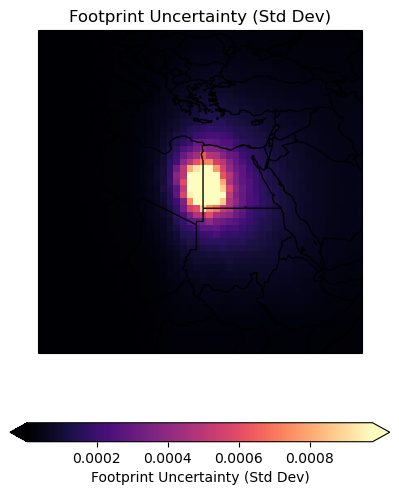

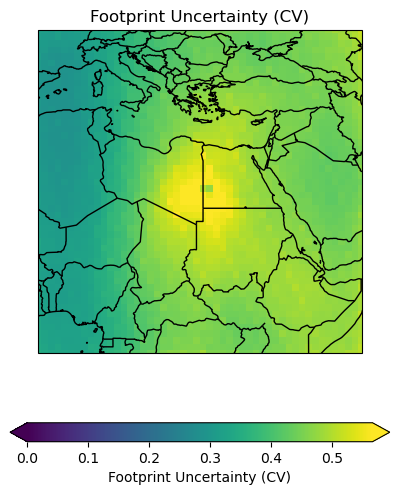

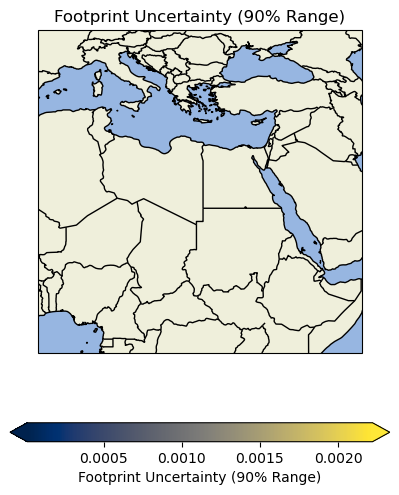

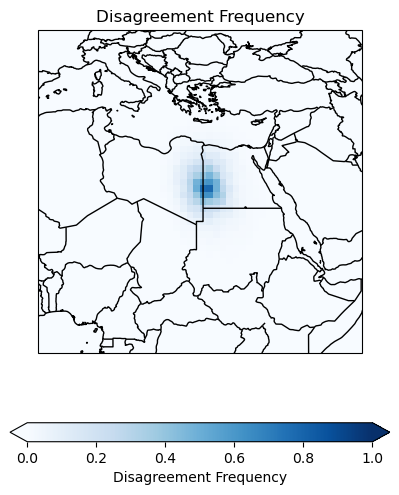

In [56]:
# Choose an uncertainty layer (2D), eg
unc_std  = std_pred.mean(dim="time")              # mean predictive std dev over time  (lat x lon)
unc_cv   = cv_pred.mean(dim="time")               # mean coefficient of variation      (lat x lon)
unc_rng  = range_90.mean(dim="time")              # mean 90% prediction range          (lat x lon)
disc_frq = disagreement_mask.mean(dim="time")     # frequency of disagreement          (lat x lon), in [0,1]

# Coordinates
month="*"
year="2016"
real = xr.open_mfdataset(glob.glob(f"/group/chemistry/acrg/LPDM/fp_Elena/satellite_emulated_logv4/NAME_fps_intersect_square/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_{year}{month}.nc"))
domain_lats = real.lat.values
domain_lons = real.lon.values
release_lats=real.release_lat.values
release_lons = real.release_lon.values
print(domain_lats, domain_lons)

domain_lats = unc_std.lat.values
domain_lons = unc_std.lon.values
binned_lons, binned_lats = np.meshgrid(domain_lons, domain_lats)



# Plot: std deviation (good for “how uncertain are we?”)
fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(
    ax=ax,
    binned_lons=binned_lons,
    binned_lats=binned_lats,
    metric=unc_std.values,
    metric_name="Footprint Uncertainty (Std Dev)",
    domain_lats=domain_lats,
    domain_lons=domain_lons,
    divergent=False,
    cmap="magma",                     
    vmin_vmax=[np.nanpercentile(unc_std, 1), np.nanpercentile(unc_std, 99)],
    fig=fig,
    cbar=True,
    cbar_position="bottom"
)
plt.savefig(save_path("footprint_uncertainty_std_map.png"), dpi=200)
plt.show()

# Plot: coefficient of variation (scale-free)
fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(
    ax=ax,
    binned_lons=binned_lons,
    binned_lats=binned_lats,
    metric=unc_cv.values,
    metric_name="Footprint Uncertainty (CV)",
    domain_lats=domain_lats,
    domain_lons=domain_lons,
    divergent=False,
    cmap="viridis",
    vmin_vmax=[0, np.nanpercentile(unc_cv, 99)],
    fig=fig,
    cbar=True
)
plt.savefig(save_path("footprint_uncertainty_cv_map.png"), dpi=200)
plt.show()

# Plot: 90% range (P95-P05)
fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(
    ax=ax,
    binned_lons=binned_lats,  # typo guard: keep lons/lats consistent!
    binned_lats=binned_lats,
    metric=unc_rng.values,
    metric_name="Footprint Uncertainty (90% Range)",
    domain_lats=domain_lats,
    domain_lons=domain_lons,
    divergent=False,
    cmap="cividis",
    vmin_vmax=[np.nanpercentile(unc_rng, 1), np.nanpercentile(unc_rng, 99)],
    fig=fig,
    cbar=True
)
plt.savefig(save_path("footprint_uncertainty_range90_map.png"), dpi=200)
plt.show()

# Plot: disagreement frequency (0–1)
fig, ax = plt.subplots(figsize=(7,6), subplot_kw={"projection": ccrs.PlateCarree()})
plot_binned_map(
    ax=ax,
    binned_lons=binned_lons,
    binned_lats=binned_lats,
    metric=disc_frq.values,
    metric_name="Disagreement Frequency",
    domain_lats=domain_lats,
    domain_lons=domain_lons,
    divergent=False,
    cmap="Blues",
    vmin_vmax=[0, 1],
    fig=fig,
    cbar=True
)
plt.savefig(save_path("disagreement_frequency_map.png"), dpi=200)
plt.show()


# Legacy code (Elena's original notebook content)
## loading the data for one of the models

In [ ]:
model_name = "satellite_clever2_50_[6,12]_vB_logv3_weightedbytruth_assym_C_seed5"
mod = ModelEv(model_name, size=50, validation_set="0[1-3]", test_set="*", val_year="2016", test_year="2016", check_validation_overlap=True, path_to_files="/group/chemistry/acrg/ef17148/trained_satellite_models/")
# loads the model into a ModelEv object. by default it has the parameters above, which validate on Jan-March (stored in mod.preds_val) and keeps the rest in mod.preds_test 
# setting "check_validation_overlap=False" will keep all the footprints in mod.preds_test

loading data from /group/chemistry/acrg/ef17148/trained_satellite_models/satellite_clever2_50_[[]6,12[]]_vB_logv3_weightedbytruth_assym_C_seed5/predictions/preds_2016*.nc
using validation data: 20160[1-3] and test data: 2016*. Checking overlap between the two: True


/user/home/kr21883/miniconda3/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 311 times more chunks
  return self.array[key]


In [62]:
"""
mod.preds_test has a naming structure (i acknowledge, confusing):
- fps: the original footprints (native data space)
- trans_fp: the original footprints, transformed according to the input transform (transformed data space)
- predictions: the predictions of the model, untouched (transformed data space)
- trans_predictions: the predictions of the model, transformed back to the original data space (native data space)
"""
mod.preds_test

<xarray.Dataset>
Dimensions:            (time: 4243, lat: 50, lon: 50)
Coordinates:
  * time               (time) datetime64[ns] 2016-04-01T15:29:20 ... 2016-12-...
  * lat                (lat) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * lon                (lon) int64 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
Data variables:
    predictions        (time, lat, lon) float32 -2.114 -2.18 ... 0.1506 0.5178
    trans_predictions  (time, lat, lon) float32 6.109e-07 ... 0.0003045
    fp                 (time, lat, lon) float64 6.866e-05 ... 0.0002823
    trans_fp           (time, lat, lon) float32 -0.1285 -0.0415 ... 0.4849
Attributes:
    creation_date:  2024-02-11 15:41:59.635325

In [63]:
# threshold the model to remove the lower values. stores these predictions in mod.pred_fluxes["thr"]
mod.get_adjusted_models(which="thr_only")

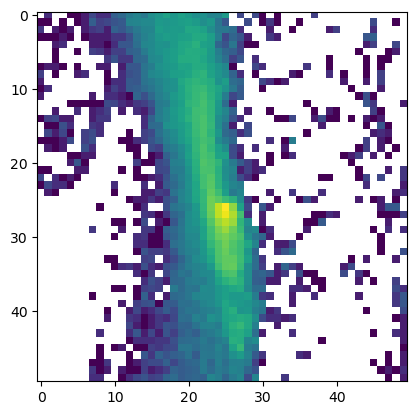

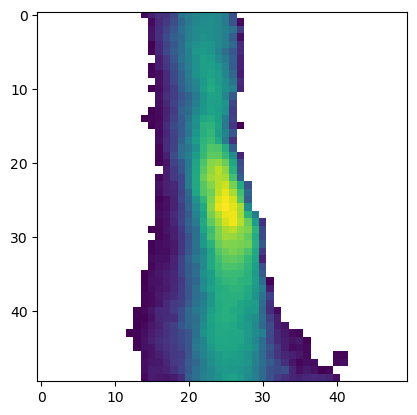

In [ ]:
t = 16#t+5
plt.imshow(np.log10(mod.preds_test.fp[t]))
plt.show()
plt.imshow(np.log10(mod.preds_test.thr[t]))
plt.show()

using UNIFORM fluxes!
USING NO UNITS TRANSFORM on the fluxes! this may have changed


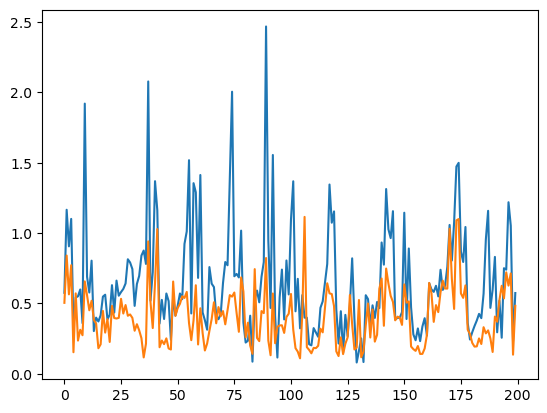

In [ ]:
# get_fluxes by default calculates the mole fraction using uniform fluxes, ie summing over the footprints
mod.get_fluxes()

window_n = 5
window_size = 200
plt.plot(mod.true_flux[window_n*window_size:(1+window_n)*window_size])
plt.plot(mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])

In [ ]:
# OR we can load and cut the actual fluxes to get realistic above-baseline concentrations

# loads the brazil map of mole fractions
brazil_mole_fractions = load_default_brazil_emissions()

# load the true footprints to use the release_lat and release_lon,
# and select the same timepoints as the testing set
true_fps = load_fps("/group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc")
true_fps = true_fps.sel(time=mod.preds_test.time)

cut_flux = cut_emissions_data(brazil_mole_fractions, true_fps, 50)
cut_flux = cut_mole_fraction.transpose([2,0,1])
# now cut_flux is in the same shape as mod.pred_fluxes["thr"], so we can plot it
mod.get_fluxes(cut_flux)

Text(0, 0.5, 'ppb')

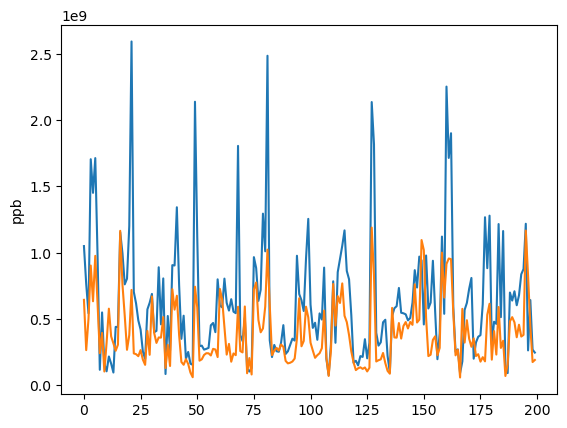

In [69]:
window_n = 3#window_n+1
window_size = 200
plt.plot(1e9*mod.true_flux[window_n*window_size:(1+window_n)*window_size])
plt.plot(1e9*mod.pred_fluxes["thr"][window_n*window_size:(1+window_n)*window_size])
plt.ylabel("ppb")